In [1]:
from main import peaks_vs_thresholds, pulse_analysis
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
from glob import glob
from scipy.optimize import curve_fit
import re
import figures.functions as ft
from scipy.fft import fft
import pandas as pd
import pickle
import scipy.constants as sc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from KID_S21 import loop_over_S21_files
from analib import KIDs
from analib.split_largefile import split_hdf5
import analib.functions as ft
from scipy.ndimage import label
import pickle
from natsort import natsorted
from itertools import groupby

%matplotlib widget

In [143]:
name = 'KID26'
# pulse_models = {}
# pulse_models[name] = {} 
# wls = ['BF dark', '3.8um off', '3.8um', '8.5um', '18.5um off', '18.5um', 'ADR dark', '25um off', '25um']
# for wl in wls:
#     pulse_models[name][wl] = {}

with open(r'KID26.pkl', 'rb') as f:
    pulse_models = pickle.load(f)

In [144]:
dir = r"D:\Data\LT218Chip1_BF_20221103_MIR3_8\12KIDs mono on 3800 long\TD_Power"
dir = r'D:\Data\LT218Chip1_BF_20240116_MIR18_5\12KIDs_185um_BB160K\TD_Power'
dir = r'D:\Data\LT218Chip1_BF_20221025_MIR8_5\12KIDs mono off long\TD_Power'
info_files = natsorted(glob(dir + '\*TDvis0*_info.dat'))
kid_table = np.zeros((27, 2))
kid_table[:, 0] = np.arange(27)
f0s = np.load(r'D:\Data\LT218_MUX\LT218_27f0s_from_VNA.npy')
f0s_meas = []
print(f0s)
for file in info_files:
    id = int(re.findall('KID\d+', file)[0][3:])
    f0_meas = ft.get_info(file)[0]
    f0s_meas.append(f0_meas)
    id_main = np.argmin(np.absolute(f0_meas - f0s))
    if kid_table[id_main,1] != 0:
        print(f"Warning: KID{kid_table[id_main,1]} with f0 {f0s[id_main]} overwritten by KID{id} with f0 {f0_meas}")
    kid_table[id_main,1] = id
    # print(id_main, id)
kid_table[25,1] = 23
kid_table
fig, ax = plt.subplots()
ax.plot()

[1.69278125 1.95660156 2.58342969 2.61678125 2.6168125  2.67735937
 2.71714062 2.73374219 3.17310938 3.17573438 3.1938125  3.215625
 3.23465625 3.2676875  3.76626562 3.84822656 3.84950781 3.85249219
 3.87610156 3.88857812 4.3858125  4.49208594 4.54497656 4.54872656
 4.58685156 4.59755469 4.6039375 ]


array([[ 0.,  0.],
       [ 1.,  0.],
       [ 2.,  0.],
       [ 3.,  0.],
       [ 4.,  0.],
       [ 5.,  3.],
       [ 6.,  0.],
       [ 7.,  5.],
       [ 8.,  0.],
       [ 9.,  0.],
       [10.,  8.],
       [11.,  9.],
       [12., 10.],
       [13.,  0.],
       [14., 13.],
       [15.,  0.],
       [16.,  0.],
       [17., 16.],
       [18., 17.],
       [19.,  0.],
       [20.,  0.],
       [21.,  0.],
       [22., 20.],
       [23., 21.],
       [24.,  0.],
       [25., 23.],
       [26., 24.]])

Secondaries/Outliers/Total = 1/3/207
Optimal filter constructed with 204 pulses and 24015 noise segments
Analysed 10 out of 10 files
Analysed 10 out of 10 files
Secondaries/Outliers/Total = 1/3/199
Nr of neg pulses at lowest threshold: 358

R = 10.36, Rsn = 12.31, 196 pulses
tqp = 55 +- 0.5 us


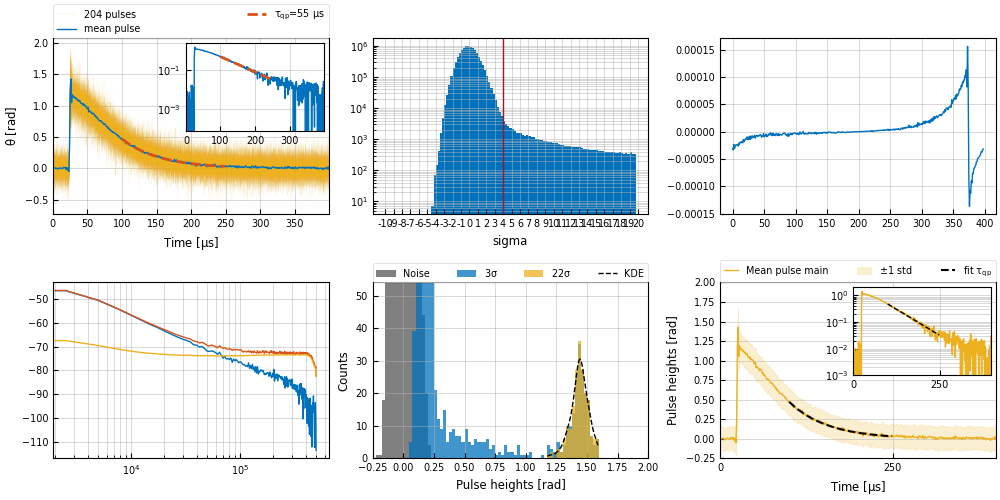

In [145]:
wl = '3.8um'
kid = 24
pread = 113
file_type = 'vis'
pw = 375
pw_offset = 25
filter_type = 'exp'
lifetime = 55
fit_tqp = [100, 250]

dir_on = r"D:\Data\LT218Chip1_BF_20221103_MIR3_8\12KIDs mono on 3800 long\TD_Power"
chuncksize = 10
noise_mph = 4
pulse_mph = 22
doubles_fraction = 4
nr_stds = [3, 22]
nr_chuncks = [1, 1]


pulse_models[name][wl] = peaks_vs_thresholds(dir_on, kid, pread, file_type, noise_mph, pulse_mph, pw, pw_offset, lifetime, nr_stds, 
                             nr_chuncks, chuncksize, filter_type, fit_tqp, doubles_fraction=doubles_fraction)

Secondaries/Outliers/Total = 12/16/1140
Optimal filter constructed with 1116 pulses and 50000 noise segments
Analysed 200 out of 200 files
Analysed 200 out of 200 files
Secondaries/Outliers/Total = 57/98/5240
Nr of neg pulses at lowest threshold: 17924

R = 5.97, Rsn = 11.16, 5117 pulses
tqp = 54 +- 0.3 us


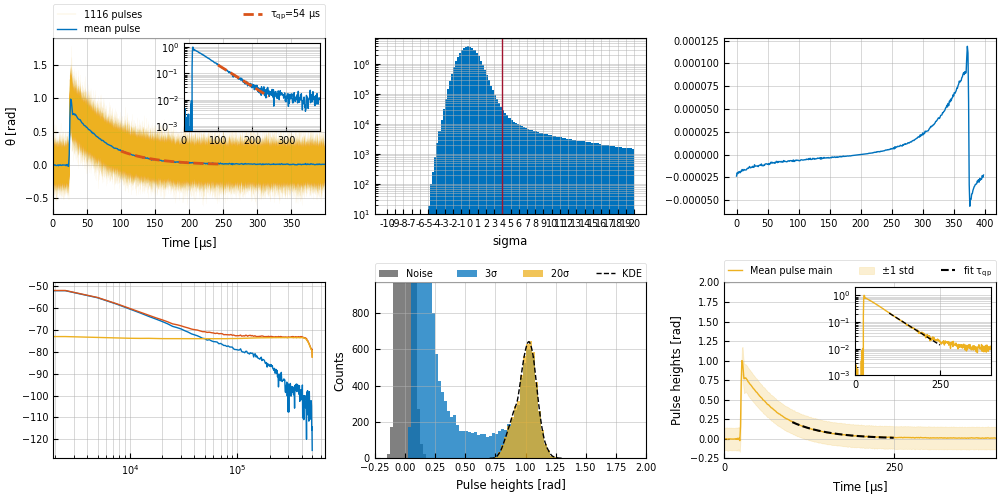

In [25]:
kid = 24
pread = 113
file_type = 'vis'
pw = 375
pw_offset = 25
filter_type = 'exp'
lifetime = 55
fit_tqp = [100, 250]

dir_on = r'D:\Data\LT218Chip1_BF_20221025_MIR8_5\12KIDs mono off long\TD_Power'
chuncksize = 40
noise_mph = 4
pulse_mph = 20
doubles_fraction = 4
nr_stds = [3, 20]
nr_chuncks = [None, None]

wl = '8.5um'

pulse_models[name][wl] = peaks_vs_thresholds(dir_on, kid, pread, file_type, noise_mph, pulse_mph, pw, pw_offset, lifetime, nr_stds, 
                             nr_chuncks, chuncksize, filter_type, fit_tqp, doubles_fraction=doubles_fraction)


Secondaries/Outliers/Total = 1/21/457
Optimal filter constructed with 436 pulses and 50000 noise segments
Analysed 40 out of 40 files
Analysed 40 out of 40 files
Secondaries/Outliers/Total = 1/21/457
Nr of neg pulses at lowest threshold: 1342

R = 3.23, Rsn = 5.86, 436 pulses
tqp = 68 +- 0.4 us


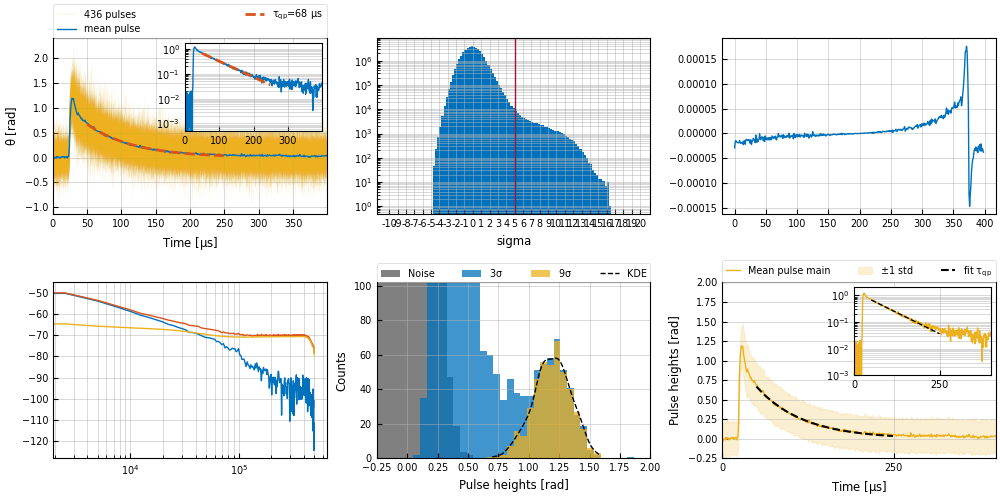

In [26]:
kid = 25
pread = 117
file_type = 'vis'
pw = 375
pw_offset = 25
filter_type = 'exp'
lifetime = 70
fit_tqp = [50, 250]

dir_on = r'D:\Data\LT218Chip1_BF_20240116_MIR18_5\12KIDs_185um_BB160K\TD_Power'
chuncksize = 40
noise_mph = 5
pulse_mph = 9
doubles_fraction = 2
nr_stds = [3, 9]
nr_chuncks = [1, 1, 1]

wl = '18.5um'

pulse_models[name][wl] = peaks_vs_thresholds(dir_on, kid, pread, file_type, noise_mph, pulse_mph, pw, pw_offset, lifetime, nr_stds, 
                             nr_chuncks, chuncksize, filter_type, fit_tqp, doubles_fraction=doubles_fraction, binsize=0.055)

Secondaries/Outliers/Total = 2/5/668
Optimal filter constructed with 662 pulses and 50000 noise segments
Analysed 40 out of 40 files
Analysed 40 out of 40 files
Secondaries/Outliers/Total = 1/6/458
Nr of neg pulses at lowest threshold: 1661

R = 3.29, Rsn = 5.70, 452 pulses
tqp = 77 +- 0.5 us


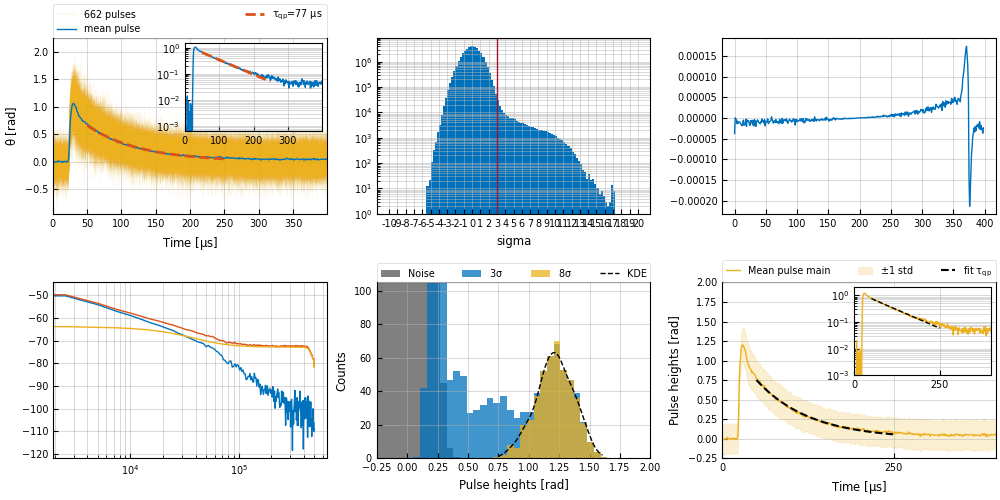

In [27]:
kid = 24
pread = 115
file_type = 'vis'
pw = 375
pw_offset = 25
filter_type = 'exp'
lifetime = 75
fit_tqp = [50, 250]

dir_on = r'D:\Data\LT218Chip1_ADR_20240506_MIR24\12KIDs_3Pread_TD40s_1MHz_BB24K\TD_Power'
chuncksize = 40
noise_mph = 3
pulse_mph = 5
doubles_fraction = 2
nr_stds = [3, 8]
nr_chuncks = [1, 1]

wl = '25um'

pulse_models[name][wl] =  peaks_vs_thresholds(dir_on, kid, pread, file_type, noise_mph, pulse_mph, pw, pw_offset, lifetime, nr_stds, 
                             nr_chuncks, chuncksize, filter_type, fit_tqp, doubles_fraction=doubles_fraction, binsize=0.055)

c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)


Q_bf_dark =  34158.19421243834


c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


Q_38um off =  32693.101364756865
Q_38um =  32385.789651672796


c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\Khalil.py:84: RuntimeWarning: invalid value encountered in sqrt
  t = (  np.cbrt(-np.sqrt(discriminant) + a_nonlin/8 + y0**3/27 + y0/12)
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\Khalil.py:85: RuntimeWarning: invalid value encountered in sqrt
  + np.cbrt( np.sqrt(discriminant) + a_nonlin/8 + y0**3/27 + y0/12))
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\Khalil.py:89: RuntimeWarning: invalid value encountered in divide
  S21 = np.abs(1 - (Q/Qc * (1 + 2j * Q * dw/w0

...

c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)


Q_185um_3K =  52663.45304488794


c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)


Q_185um_160K =  52477.72634837962
Q_25um_dark =  27303.689050933666
Q_25um_3K =  62769.85193744027 0.6373910585258151
Q_25um_24K =  62509.487327681185


c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)
c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\mir-kids\.venv\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
c:\Users\wilbertr\ownCloud2\

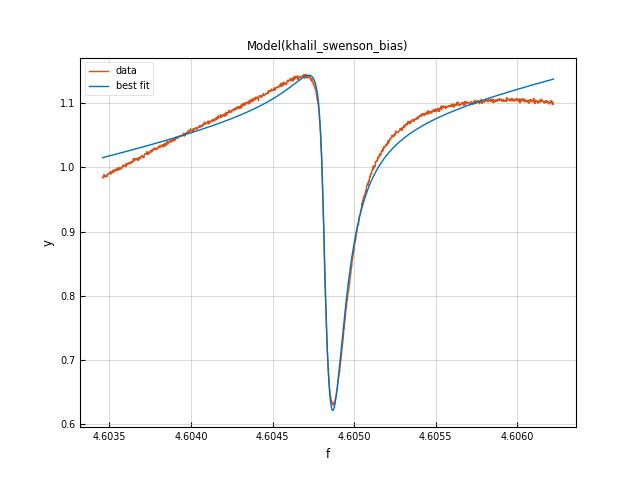

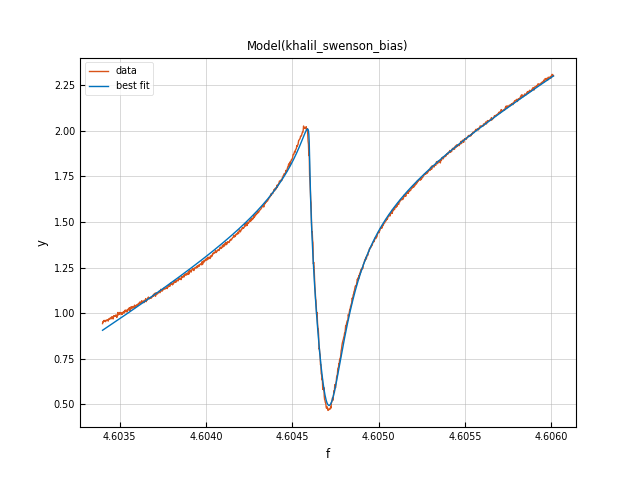

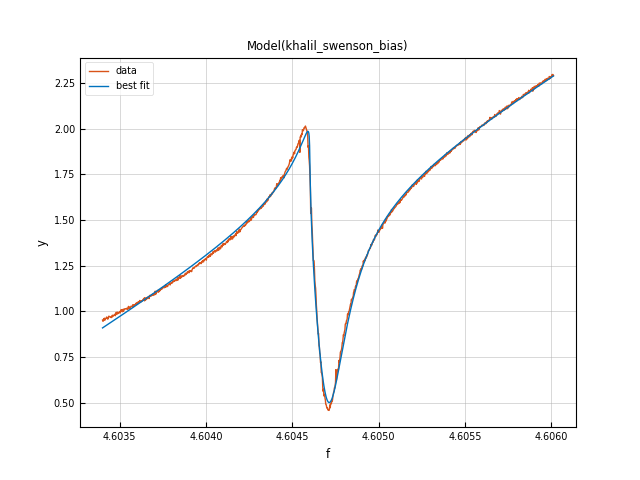

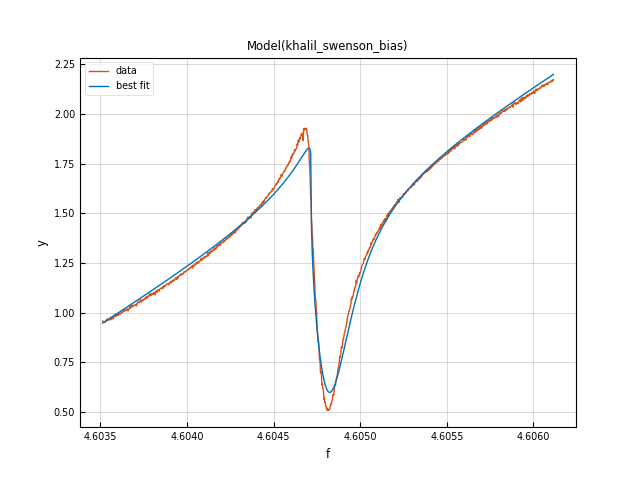

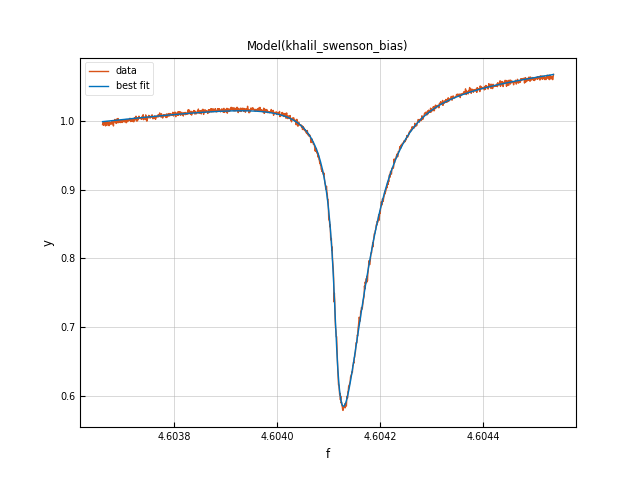

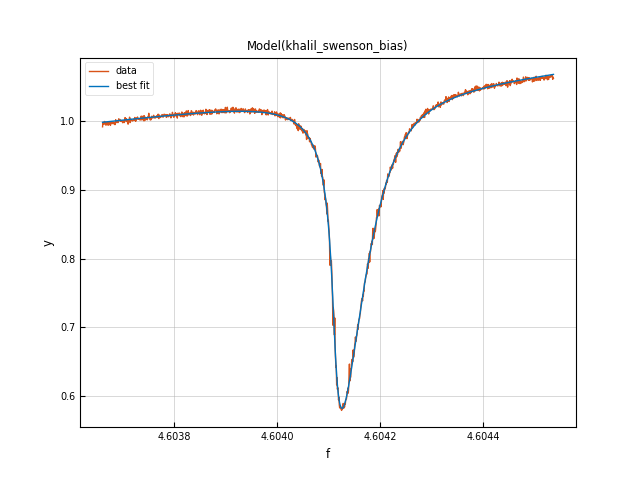

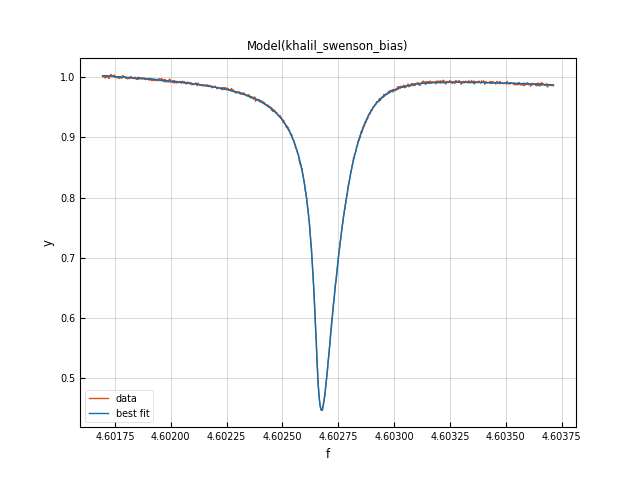

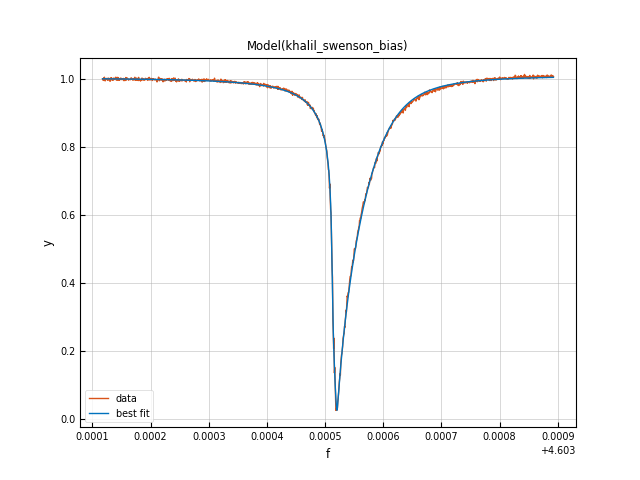

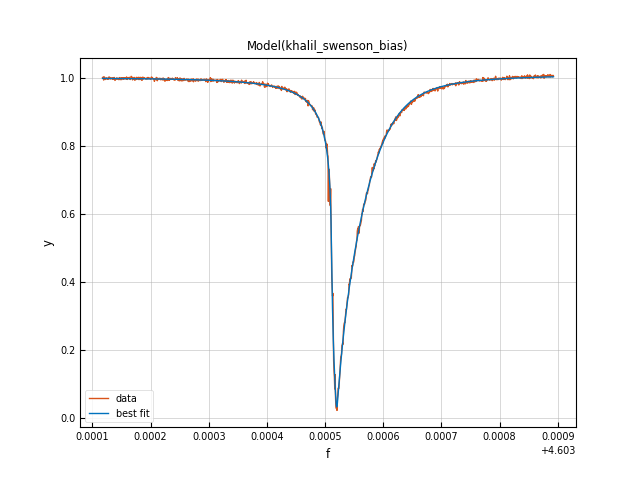

In [71]:
kid = 24
pread = 113
wl = 'BF dark'
pulse_models[name][wl] = {}
dir = r'D:\Data\LT218Chip1_BF_20230208_dark\FFT\Power/'
df = loop_over_S21_files(dir, kid, pread=112, plot=True, model='khalilswensonbias', method='least squares', append='__S21dB')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
print('Q_bf_dark = ', df['Ql'].iloc[0])



wl = '3.8um off'
pulse_models[name][wl] = {}
dir = r'D:\Data\LT218Chip1_BF_20221103_MIR3_8\12KIDs mono off\FFT\Power/'
df = loop_over_S21_files(dir, kid=kid, pread=113, plot=True, model='khalilswensonbias', method='least squares', append='__S21dB')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
print('Q_38um off = ', df['Ql'].iloc[0])

wl = '3.8um'
dir = r'D:\Data\LT218Chip1_BF_20221103_MIR3_8\12KIDs mono on 3800 long\FFT\Power/'
df = loop_over_S21_files(dir, kid=kid, pread=113, plot=True, model='khalilswensonbias', method='least squares', append='__S21dB')
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
print('Q_38um = ', df['Ql'].iloc[0])


wl = '8.5um'
dir = r'D:\Data\LT218Chip1_BF_20221025_MIR8_5\12KIDs mono off long\FFT\Power/'
df = loop_over_S21_files(dir, kid=kid, pread=113, plot=True, model='khalilswensonbias', method='least squares', append='__S21dB')
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
print('Q_85um = ', df['Ql'].iloc[0])


kid = 25
pread = 117
wl = '18.5um off'
pulse_models[name][wl] = {}
dir = r'D:\Data\LT218Chip1_BF_20240116_MIR18_5\12KIDs_185um_BB3K\FFT\Power/'
df = loop_over_S21_files(dir, kid, pread=118, plot=True, model='khalilswensonbias', method='least squares', append='__S21dB')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
print('Q_185um_3K = ', df['Ql'].iloc[0])

wl = '18.5um'
dir = r'D:\Data\LT218Chip1_BF_20240116_MIR18_5\12KIDs_185um_BB160K\FFT\Power/'
df = loop_over_S21_files(dir, kid, pread=118, plot=True, model='khalilswensonbias', method='least squares', append='__S21dB')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
print('Q_185um_160K = ', df['Ql'].iloc[0])

kid = 24
pread = 113
wl = 'ADR dark'
pulse_models[name][wl] = {}
dir = r'D:\Data\LT218Chip1_ADR_20240605_MIR24_dark\12KIDs_3Pread_100s_1MHz\FFT\Power/'
df = loop_over_S21_files(dir, kid, pread=112, plot=True, model='khalilswensonbias', method='least squares', append='__S21db')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['kid'] = kid
pulse_models[name][wl]['pread'] = pread
print('Q_25um_dark = ', df['Ql'].iloc[0])

pread = 115
wl = '25um off'
pulse_models[name][wl] = {}
dir = r'D:\Data\LT218Chip1_ADR_20240506_MIR24\12KIDs_3Pread_TD40s_1MHz_BB3K\FFT\Power/'
df = loop_over_S21_files(dir, kid, pread=116, plot=True, model='khalilswensonbias', method='least_squares', append='__S21dB')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['pread'] = pread
pulse_models[name][wl]['kid'] = kid
print('Q_25um_3K = ', df['Ql'].iloc[0], df['a_nonlin'].iloc[0])

wl = '25um'
dir = r'D:\Data\LT218Chip1_ADR_20240506_MIR24\12KIDs_3Pread_TD40s_1MHz_BB24K\FFT\Power/'
df = loop_over_S21_files(dir, kid, pread=116, plot=True, model='khalilswensonbias', method='least_squares', append='__S21dB')
pulse_models[name][wl]['Q'] = df['Ql'].iloc[0]
pulse_models[name][wl]['dir'] = dir.replace('FFT\Power/', 'TD_Power')
pulse_models[name][wl]['pread'] = pread
pulse_models[name][wl]['kid'] = kid
print('Q_25um_24K = ', df['Ql'].iloc[0])

In [72]:
# with open(r'KID26.pkl', 'wb') as f:
#     pickle.dump(pulse_models, f)

In [2]:
with open(r'KID26.pkl', 'rb') as f:
    kid_dict = pickle.load(f)

wls = ['3.8um', '8.5um', '18.5um', '25um']
name = 'KID26'
colors = ['b', 'y', 'o', 'p']

In [ ]:
m, n = 4, 4
id = 'abcd;efgh;ijkl;mnop'
fig, axes = plt.subplot_mosaic(id, figsize=(12, 12), constrained_layout=True)

for i, a in enumerate(id):
    if a != ';':
        axes[a].plot(kid_dict[name][wls[0]]['pulses'][i])
    else:
        i -= 1

In [3]:
def plot_hist(ax, H_opts, H_noise, nr_stds, binsize, color, ncols=4, scale=1, binsize_override=None, xlim=None):
    if binsize_override is not None:
        binsize = binsize_override
    bins = np.arange(-2, 3, binsize/scale)
    ax.hist(H_noise/scale, bins=bins, facecolor='gray', label='Noise', zorder=0)
    _ = ax.hist(H_opts[0]/scale, bins=bins, facecolor=color, alpha=.75, label='%d$\sigma$' % (nr_stds[0]), zorder=1)
    # _ = ax.hist(H_opts[-1]/scale, bins=bins, facecolor=color, alpha=.75, label='%d$\sigma$' % (nr_stds[-1]), zorder=2)
    mean_H_opt = np.mean(H_opts[-1]/scale)
    _, y, x, _, fwhm = ft.resolving_power(H_opts[-1]/scale, binsize/scale)
    R = mean_H_opt/fwhm
    ax.plot(x, y, c='k', ls='--', label='KDE (%d$\sigma$)' % (nr_stds[-1]), lw=1,  zorder=3)
    max_y = np.amax(np.histogram(H_opts[-1]/scale, bins=bins)[0])
    ax.set_ylim([0, max_y*1.3])
    max_x = xlim
    ax.set_xlim([-.25,max_x])
    ax.set_ylabel('Counts')
    ax.set_xlabel('Pulse height [rad]')
    _, y, x, _, fwhm = ft.resolving_power(H_noise/scale, binsize/scale)
    # ax.plot(x, y, c='k', ls='--', label='R0', lw=1,  zorder=i+2)
    R0 = mean_H_opt/fwhm
    ax.legend(bbox_to_anchor=(0., .9, 1., .102), loc='upper left',
                                ncols=ncols, mode="expand", borderaxespad=0., handlelength=1)
    return R, R0

def fano(wl, Tc, J=0):
    Eph = sc.h * sc.c / wl
    F = 0.2
    Delta = 1.76 * sc.k * Tc
    eta_pb = 0.59
    return 1/(2*np.sqrt(2*np.log(2))) * np.sqrt(eta_pb * Eph / (Delta * (F+J)))

def tau_qp(x, a, tqp):
    return a*np.exp(-x/tqp)

55.26633034864832 0.10226498065710883


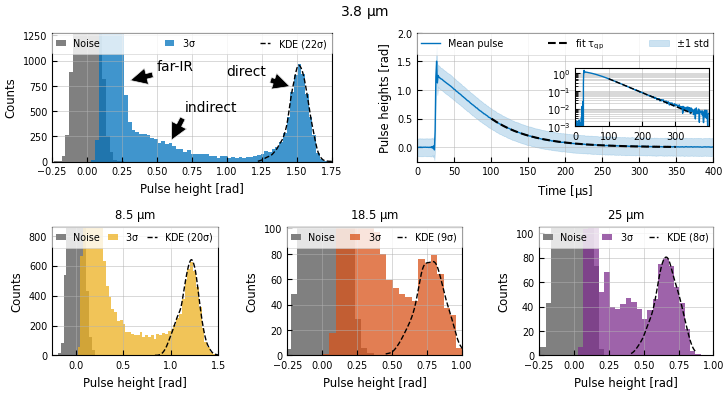

In [17]:
fig, axes = plt.subplot_mosaic('aaabbb;ccddee', constrained_layout=True, figsize=(18.5/2.54, 10/2.54))
axs = 'acde'
ncols = [4, 4, 4, 4]

xlim = [1]
i = 0
Q_bf_dark = kid_dict[name]['BF dark']['Q']
binsize_override = [None, None, 0.07, 0.07]
xlims = [1.75, 1.5, 1, 1]
for key in wls:
    item = kid_dict[name][key]
    ax = axes[axs[i]]
    R, item['R0'] = plot_hist(ax, item['Hopts'], item['Hopt noise'], item['stds'], item['binsize'], colors[i], ncols=ncols[i], scale=item['Q']/Q_bf_dark, binsize_override=binsize_override[i], xlim=xlims[i])
    title = '%s $\mu m$' % wls[i][:-2]
    if i:
        ax.set_title(title)
    else:
        fig.suptitle(title, fontsize=10)
    i += 1
ax = axes['a']
ax.annotate('far-IR', xy=(0.3, 800), xytext=(0.5, 900),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('indirect', xy=(.6, 200), xytext=(.7, 500),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('direct', xy=(1.46,740), xytext=(1, 850),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax = axes['b']
wl = '3.8um'
c='b'
scale = kid_dict[name][wl]['Q']/Q_bf_dark
pulses = kid_dict[name][wl]['pulses'] / scale
mean_pulse = np.mean(pulses, axis=0)    
std_pulse = np.std(pulses, axis=0)
t = np.arange(len(mean_pulse))
fit_tqp = [100, 350]
popt, pcov = curve_fit(tau_qp, t[fit_tqp[0]:fit_tqp[1]], mean_pulse[fit_tqp[0]:fit_tqp[1]], p0=[1, 200])
tqp = popt[1]
perr = np.sqrt(np.diag(pcov))
x = np.arange(fit_tqp[0], fit_tqp[1]) 
y = tau_qp(x, *popt)
print(tqp, perr[1])
ax.plot(t, mean_pulse, c=c, label='Mean pulse')
ax.plot(x, y, c='k', ls='--', lw=1.5, label='fit $\\tau_{qp}$', zorder=3)
ax.fill_between(t, mean_pulse - std_pulse, mean_pulse + std_pulse, color=c, alpha=.2, label='$\pm1$ std')
xticks = np.linspace(t[0], t[-1]+1, 9, endpoint=True, dtype=int)    
ax_inset = inset_axes(ax, width="45%", height="45%", loc='center right')
ax_inset.semilogy(t, mean_pulse, c=c, label='mean pulse')
ax_inset.semilogy(x, y, c='k', ls='--', lw=1, label='fit $\\tau_{qp}$', zorder=3)
ax_inset.set_xlim([t[0], t[-1]+1])
ax_inset.set_ylim([1e-3, 2])
ax_inset.set_xticks(xticks[:-1:2])
ax_inset.set_xticklabels(xticks[:-1:2])
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
ax.set_xlim([t[0], t[-1]+1])
ax.set_ylim([-.25, 2])
ax.set_ylabel('Pulse heights [rad]')
ax.set_xlabel('Time [$\mu$s]')
ax.legend(bbox_to_anchor=(0., .9, 1., .102), loc='upper left',ncols=3, mode="expand", borderaxespad=0., handlelength=2)
plt.savefig('figures/resolving powers KID26.pdf')

0.001530625097458256


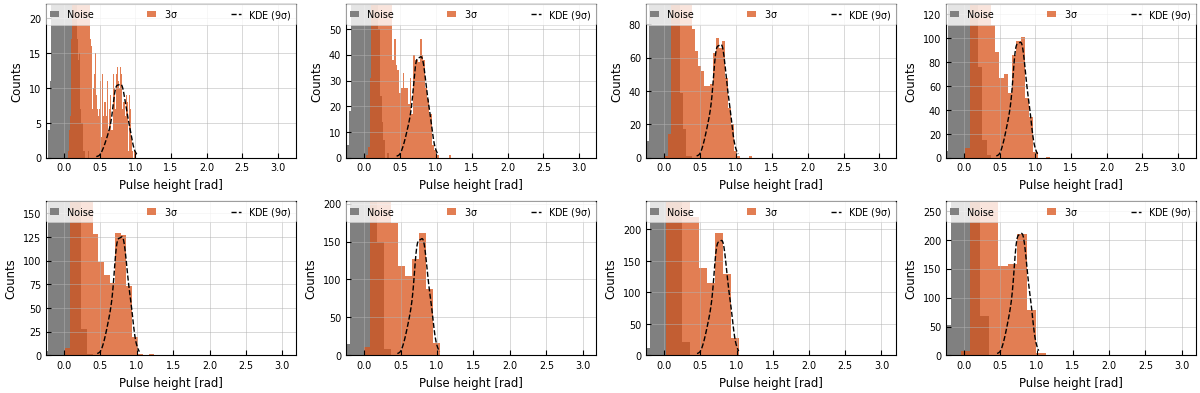

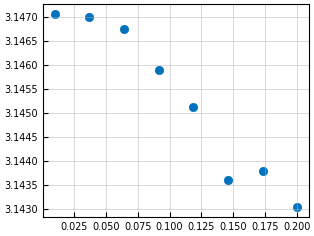

In [5]:
fig, axes = plt.subplot_mosaic('abcd;efgh', constrained_layout=True, figsize=(12, 10/2.54))
axs = 'abcdefgh'
ncols = [4, 4, 4, 4]

xlim = [1]
Q_bf_dark = kid_dict[name]['BF dark']['Q']
binsize_override = np.linspace(1e-2, 2e-1, len(axs))
key = '18.5um'
color= 'o'
Rs = []
for i, binsize in enumerate(binsize_override):
    item = kid_dict[name][key]
    ax = axes[axs[i]]
    R, _ = plot_hist(ax, item['Hopts'], item['Hopt noise'], item['stds'], item['binsize'], color, scale=item['Q']/Q_bf_dark, binsize_override=binsize)
    Rs.append(R)
fig, ax = plt.subplots(constrained_layout=True, figsize=(8/2.54, 6/2.54))
ax.scatter(binsize_override, Rs)
print(np.std(Rs))
# plt.savefig('figures/resolving powers KID26.pdf')

In [9]:
dir = r'D:\Data\LT218_MUX'
append_keys = ['pulses', 't', 'mean per seg']
pkl_files = natsorted(glob(dir + '\\7kids_10000s\\fast*.pkl'))
for i, file in enumerate(pkl_files):
    with open(file, 'rb') as f:
        if i == 0:
            total_pkl = pickle.load(f)
            print()
        else:
            seg_pkl = pickle.load(f)
            for kid, item in total_pkl.items():
                if len(seg_pkl[kid]['t']) == len(seg_pkl[kid]['pulses']):
                        item['t'].extend(seg_pkl[kid]['t'])
                        item['pulses'].extend(seg_pkl[kid]['pulses'])
                        item['mean per seg'].append(seg_pkl[kid]['mean per seg'])
                        item['T'] += seg_pkl[kid]['T']
                if len(seg_pkl[kid]['neg t']) == len(seg_pkl[kid]['neg pulses']):
                        item['neg t'].extend(seg_pkl[kid]['neg t'])
                        item['neg pulses'].extend(seg_pkl[kid]['neg pulses'])
                else:
                    print('ERROR: Mismatch in lengths for nr of pulses and timestamps in %s' % kid)
for kid, item in total_pkl.items():
    pulses = np.array(item['pulses'])
    neg_pulses = np.array(item['neg pulses'])
    print(kid, pulses.shape, neg_pulses.shape) 


KID21 (8169, 320) (1900, 320)
KID22 (6682, 320) (9, 320)
KID23 (1959, 320) (1048, 320)
KID24 (3015, 320) (457, 320)
KID25 (462, 320) (2304, 320)
KID26 (12843, 320) (1583, 320)


25 33130 0.0007546030787805615
[1520.90220339 3804.97154867 4738.8225495  7211.5300096  7566.31498342
 1520.90223411 3804.9715241  6293.32399411 6393.75161958 7211.53002086
 7566.31500083 3804.9715241  3804.97152307 3974.34245632 5672.26096128
 7566.31500493 3804.97151693 3804.97153536 3974.34248909 4738.82256691
 5672.26097459 6293.32397978 6393.75163699 7211.53003418 7566.31499776]
[0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 2. 3. 3. 3. 3. 4. 5. 5. 5. 5. 5. 5. 5.
 5.]
[2, 6, 2, 2, 2, 2, 2, 3, 4]


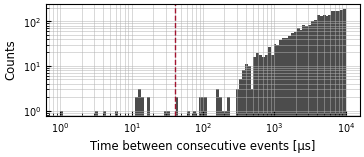

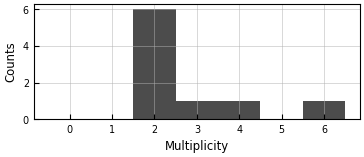

In [10]:
threshold = 40e-6

ts = []
ids = []
i = 0
for kid, item in total_pkl.items():
    t = np.array(item['t'])
    ts.extend(item['t'])
    ids.extend(np.ones(len(item['t']))*i)
    i += 1
ts = np.array(ts)
ids = np.array(ids)

argsort = np.argsort(ts)
rev_argsort = np.argsort(argsort)
sorted_ts = ts[argsort]
diffs = np.diff(sorted_ts)
too_close = (diffs<=threshold)
good = np.ones(ts.shape, dtype=int)
good[1:] -= too_close
good[:-1] -= too_close
good = (good == True)
labeled_array, num_features = label(~good)
multiplicity = np.zeros_like(good, dtype=int)
for label_id in range(1, num_features + 1):
    multiplicity[labeled_array == label_id] = np.sum(labeled_array == label_id)
multiplicities = [sum(1 for _ in group) for value, group in groupby(~good) if value]

coincident = np.sum(~good)
print(coincident, len(ts), coincident/len(ts))
rev_good = good[rev_argsort]
rev_multiplicty = multiplicity[rev_argsort]
i = 0
print(ts[~rev_good])
print(ids[~rev_good])
for kid, item in total_pkl.items():
    item['single events'] = rev_good[ids==i].astype(bool)
    item['multiplicity'] = rev_multiplicty[ids==i].astype(int)
    i += 1


fig, axes = plt.subplot_mosaic('a', figsize=(18.5/2/2.54, 4/2.54), constrained_layout=True)
ax = axes['a']
ax.hist(diffs*1e6, bins=np.logspace(0, 4, 100), facecolor='k', alpha=0.7)
ax.axvline(threshold*1e6, color='r', linestyle='--')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time between consecutive events [µs]')
ax.set_ylabel('Counts')
# plt.savefig('figures/LT218_KID26_coincidences.pdf')

fig, axes = plt.subplot_mosaic('a', figsize=(18.5/2/2.54, 4/2.54), constrained_layout=True)
ax = axes['a']
ax.hist(multiplicities, bins=np.arange(-.5, 7, 1), facecolor='k', alpha=0.7)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Multiplicity')
ax.set_ylabel('Counts')
print(multiplicities)


coincident events:  8  out of  12843


Text(0.5, 0, 'Pulse height [rad]')

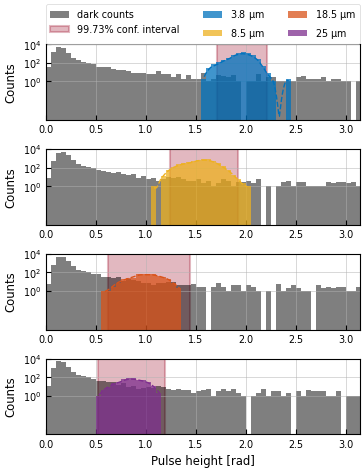

In [11]:
with open(r'D:\Data\LT218_MUX\7kids_10000s\fastreadout_noise.00011_seg000.pkl', 'rb') as f:
    mux = pickle.load(f)

Q_mux = mux[name]['Q']
colors = ['b', 'y', 'o', 'p']
wls = ['3.8um', '8.5um', '18.5um', '25um']
fig, axes = plt.subplot_mosaic('a;b;c;d', figsize=(18.5/2/2.54, 12/2.54), constrained_layout=True, sharey=True)
single_event_mask = total_pkl[name]['single events']
print('coincident events: ', np.sum(~single_event_mask), ' out of ', len(single_event_mask))
axids = 'abcd'
nr_stds = [2, 3, 4]
for nr in nr_stds:
    for i, wl in enumerate(wls):
        if nr == nr_stds[0]:
            kid_dict[name][wl]['dcr'] = {}
        bins = np.arange(0, 4, 0.05)
        Q_st = kid_dict[name][wl]['Q']
        template = kid_dict[name][wl]['pulse template'] 
        std = kid_dict[name][wl]['stds'][0]
        norm_template = template / np.max(template)
        L = round(len(norm_template)/2+1)
        nxx = mux[name]['Nxx']
        pulses = np.array(total_pkl[name]['pulses'])[single_event_mask]
        neg_pulses = np.array(total_pkl[name]['neg pulses'])
        norm_fft = fft(norm_template[:len(nxx)])
        opt_filter = norm_fft.conj() / nxx
        normalisation = np.sum((np.abs(norm_fft)**2 / nxx))
        pulses_fft = fft(pulses, axis=1)
        neg_pulses_fft = fft(neg_pulses, axis=1)
        H_mux = np.real(np.sum((opt_filter*pulses_fft), axis=1) / normalisation)
        H_st = kid_dict[name][wl]['Hopts'][-1] *(Q_mux/Q_st)
        x, y = kid_dict[name][wl]['kde']
        Ropt = kid_dict[name][wl]['Ropt']
        mu = x[np.argmax(y)]
        std = mu/Ropt / 2.355
        lims = np.array([mu - nr*std, mu + nr*std])*(Q_mux/Q_st)
        dcr = np.sum((H_mux >=lims[0])&(H_mux <= lims[1])) / total_pkl[name]['T'] * 1e3
        kid_dict[name][wl]['dcr'][str(nr)] = dcr
        # lim = (mu - 3*std)*(Q_mux/Q_st)
        # lim = np.mean(H_st) - 3*np.std(H_st)
        if nr == nr_stds[1]:
            ax = axes[axids[i]]
            ax.hist(H_st, bins=bins, alpha=.75, color=colors[i], zorder=2)
            ax.plot(x*(Q_mux/Q_st), y, color=colors[i], ls='--', zorder=2)
            _ = ax.hist(H_mux, bins=bins, label='dark counts', color='k', alpha=0.5, zorder=1)
            ax.fill_between(lims, 1e4, color='r', alpha=.3, linestyle= '-', lw=1.5, label='99.73% conf. interval', zorder=0)
            axes['a'].hist([], bins=bins, alpha=.75, label='%s $\mu$m' % (wl[:-2]), color=colors[i], zorder=2)
            # ax.hist(kid_dict[name][wl]['Hopts'][0] *(Q_mux/Q_st), bins=bins, alpha=.75, label='Noise', color='gray', zorder=1)
            #             # if i == 0:
            # else:
            #     ax.fill_between(lims, 1e4, color='r', alpha=.3, linestyle= '-', lw=1.5, zorder=0)
            #     ax.hist(kid_dict[name][wl]['Hopts'][0] *(Q_mux/Q_st), bins=bins, alpha=.75, color='gray', zorder=1)
            #     _ = ax.hist(H_mux, bins=bins, color='k', alpha=0.5, zorder=3)
            ax.set_yscale('log')
            ax.set_ylabel('Counts')
            ax.set_ylim(None,1e4)
            yticks = np.logspace(0,4,3)
            ax.set_yticks(yticks)
            # ax.set_yticklabes
            ax.set_xlim(0,np.pi)
            ax.grid(True, which='major')
            ax.grid(False, which='minor')
            # ax.set_title('%s $\mu$m, $N_\mathrm{dark}$=%.1f mHz' % (wl[:-2], dcr))

axes['a'].legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',ncols=3, mode="expand", borderaxespad=0., handlelength=2)
axes['d'].set_xlabel('Pulse height [rad]')
# plt.savefig('figures/LT218_KID26_darkcountrates.pdf')


Ropts=  [np.float64(9.880842951107969), np.float64(5.971886493148149), np.float64(3.2325450915393676), np.float64(3.288373290162347)]
Reff =  [9.95080863 5.98722966 3.23496723 3.39081256]
Ris =  [16.93648445  7.09592159  3.8809489   4.21648613]
Rsns =  [np.float64(12.29713348255357), np.float64(11.15509057144325), np.float64(5.8557469475849535), np.float64(5.704729214911109)]
Ndarks = 
 [[ 1.41080599  2.51929641  3.62778683]
 [ 3.62778683  5.74399581  8.16252036]
 [10.98413234 20.35591497 34.06088743]
 [12.99956946 22.47212395 39.40179581]]


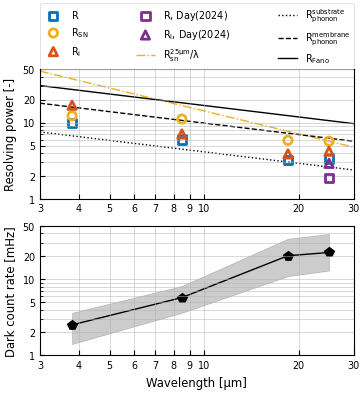

In [15]:
fig, axes = plt.subplot_mosaic('a;b', figsize=(18.5/2/2.54, 10/2.54), constrained_layout=True)
ax = axes['a']
Ropts = []
R0s = []
Reffs = []
Rsns = []
Ris = []
Rfilters = [83.47,83.47,83.55,13.48]
Ndarks = []
lambdas = []
for wl in wls:
    lambdas.append(float(wl[:-2]))
    item = kid_dict[name][wl]
    Ropts.append(item['Ropt'])
    Rsns.append(item['Rsn'])
    R0s.append(item['R0'])
    Ndarks.append([item['dcr']['2'], item['dcr']['3'], item['dcr']['4']])
lambdas = np.array(lambdas)
Reffs = np.sqrt(1/(1/np.asarray(Ropts)**2 - 1/np.asarray(Rfilters)**2))
Ris = np.sqrt(1/(1/np.asarray(Reffs)**2 - 1/np.asarray(Rsns)**2))
Ndarks = np.array(Ndarks)
ax.scatter(lambdas, Reffs, label='$R$', facecolor='None', edgecolor='b', linewidth=2, marker='s', zorder=1)
ax.scatter(lambdas, Rsns, label='$R_{SN}$', facecolor='None', edgecolor='y', linewidth=2, marker='o', zorder=2)
# ax.scatter(wls, Rsns, label='$R_0$', facecolor='y', edgecolor='y', linewidth=2, marker='o', zorder=-2)
ax.scatter(lambdas, Ris, label='$R_{i}$', facecolor='None', edgecolor='o', linewidth=2, marker='^', zorder=3)
ax.scatter(25, 1.89, label='$R$, Day(2024)', marker='s', linewidth=2, facecolor='None', edgecolor='p', zorder=3)
ax.scatter(25, 2.92, label='$R_i$, Day(2024)', marker='^', linewidth=2, facecolor='None', edgecolor='p', zorder=3)
wl = np.linspace(3, 30, 1000)
ax.plot(wl, kid_dict[name]['25um']['Rsn']*25/wl, label='$R_{sn}^{25\mu m}/\lambda$', c='y', linestyle='-.', zorder=0)
Tc_Al = 1.54
Rfano = fano(wl*1e-6, Tc_Al)
Rfano_wls = fano(lambdas*1e-6, Tc_Al, J=.38)
ax.plot(wl, fano(wl*1e-6, Tc_Al, J=3.1), label='$R^{substrate}_{phonon}$', c='k', linestyle=':', zorder=0)
ax.plot(wl, fano(wl*1e-6, Tc_Al, J=.38), label='$R^{membrane}_{phonon}$', c='k', linestyle='--', zorder=0)
ax.plot(wl, fano(wl*1e-6, Tc_Al, J=0), label='$R_{Fano}$', c='k', linestyle='-', zorder=0)
ax.set_ylabel('Resolving power [-]')
ax.set_yscale('log')
ax.set_xscale('log')
xticks = [3, 4, 5, 6, 7, 8, 9, 10, 20, 30]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]
yticks = [1, 2, 5, 10, 20, 50]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
ax.set_xlim([3,30])
ax.set_ylim([1,50])
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=3, mode="expand", borderaxespad=0.)
print('Ropts= ', Ropts)
print('Reff = ', Reffs)
print('Ris = ', Ris)
print('Rsns = ', Rsns)
print('Ndarks = \n', Ndarks)
ax = axes['b']
ax.plot(lambdas, Ndarks[:, 1], 'p-', c='k', label='$N_\mathrm{dark}$ 4 $\sigma$', linewidth=1, markerfacecolor='k', markeredgecolor='k', zorder=-3, markeredgewidth=2)
# ax.plot(wls, Ndarks[1], 'p-', c='k', label='$N_\mathrm{dark}$', linewidth=1, markerfacecolor='None', markeredgecolor='k', zorder=-3)
ax.fill_between(lambdas, Ndarks[:, 0], Ndarks[:, 2], color='k', alpha=0.2, label='3-5 $\sigma$', zorder=-4)
ax.set_ylabel('Dark count rate [mHz]')
ax.set_xlabel('Wavelength [µm]')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim([3,30])
ax.set_ylim([1,20])
xticks = [3, 4, 5, 6, 7, 8, 9, 10, 20, 30]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
yticks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]
yticks = [1, 2, 5, 10, 20, 50]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
# ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
#         ncols=3, mode="expand", borderaxespad=0.)
plt.savefig('figures/fano KID26.pdf')

In [35]:
wl = 25
fano(wl*1e-6, Tc_Al, J=0.38)/fano(wl*1e-6, Tc_Al, J=3.1)

np.float64(2.3852998076581056)

In [41]:
np.sqrt(1/((0.38+0.2)/(3.1+0.2)))

np.float64(2.385299807658105)